In [68]:
pip install yfinance pandas numpy matplotlib seaborn

In [69]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
import yfinance as yf

print("yfinance installed successfully")

yfinance installed successfully


In [71]:
import yfinance as yf

data = yf.download("^GSPC", start="2015-01-01", end="2025-01-01")

print(data.head())

[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open      Volume
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC       ^GSPC
Date                                                                      
2015-01-02  2058.199951  2072.360107  2046.040039  2058.899902  2708700000
2015-01-05  2020.579956  2054.439941  2017.339966  2054.439941  3799120000
2015-01-06  2002.609985  2030.250000  1992.439941  2022.150024  4460110000
2015-01-07  2025.900024  2029.609985  2005.550049  2005.550049  3805480000
2015-01-08  2062.139893  2064.080078  2030.609985  2030.609985  3934010000


In [72]:
# Data manipulation
import pandas as pd
import numpy as np

# Financial data
import yfinance as yf

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
data = yf.download("^GSPC", start="2010-01-01", end="2024-01-01")

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2010-01-04,1132.989990,1133.869995,1116.560059,1116.560059,3991400000
2010-01-05,1136.520020,1136.630005,1129.660034,1132.660034,2491020000
2010-01-06,1137.140015,1139.189941,1133.949951,1135.709961,4972660000
2010-01-07,1141.689941,1142.459961,1131.319946,1136.270020,5270680000
2010-01-08,1144.979980,1145.390015,1136.219971,1140.520020,4389590000


In [74]:
data.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3522 entries, 2010-01-04 to 2023-12-29
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, ^GSPC)   3522 non-null   float64
 1   (High, ^GSPC)    3522 non-null   float64
 2   (Low, ^GSPC)     3522 non-null   float64
 3   (Open, ^GSPC)    3522 non-null   float64
 4   (Volume, ^GSPC)  3522 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 165.1 KB


In [75]:
data.describe()


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
count,3522.000000,3522.000000,3522.000000,3522.000000,3.522000e+03
mean,2535.092035,2548.398393,2519.736800,2534.540220,3.939970e+09
std,1070.516829,1076.721030,1063.824066,1070.377836,9.644275e+08
min,1022.580017,1032.949951,1010.909973,1027.650024,0.000000e+00
25%,1650.479980,1656.674957,1639.840027,1649.520020,3.361888e+09
50%,2264.484985,2271.895020,2258.309937,2267.295044,3.779375e+09
75%,3274.374939,3285.877441,3251.767578,3275.787415,4.315865e+09
max,4796.560059,4818.620117,4780.979980,4804.509766,1.061781e+10


In [76]:
print(data.columns)

MultiIndex([( 'Close', '^GSPC'),
            (  'High', '^GSPC'),
            (   'Low', '^GSPC'),
            (  'Open', '^GSPC'),
            ('Volume', '^GSPC')],
           names=['Price', 'Ticker'])


In [77]:
prices = data["Close"]

In [78]:
print(prices.head())

Ticker            ^GSPC
Date                   
2010-01-04  1132.989990
2010-01-05  1136.520020
2010-01-06  1137.140015
2010-01-07  1141.689941
2010-01-08  1144.979980


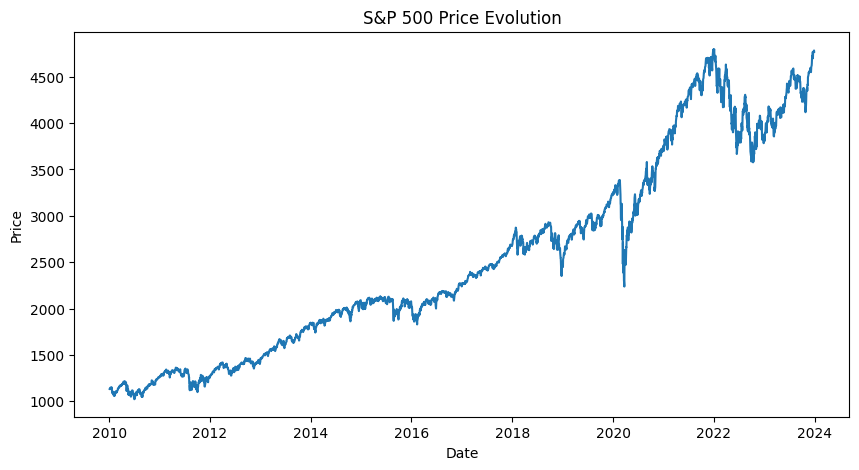

In [79]:
plt.figure(figsize=(10,5))
plt.plot(prices)
plt.title("S&P 500 Price Evolution")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [80]:
#calcule deu rendement 
returns = np.log(prices / prices.shift(1))

returns = returns.dropna()  # dropna supprime la première valeur vide
returns = returns.squeeze()
returns.head()

Date
2010-01-05    0.003111
2010-01-06    0.000545
2010-01-07    0.003993
2010-01-08    0.002878
2010-01-11    0.001745
Name: ^GSPC, dtype: float64

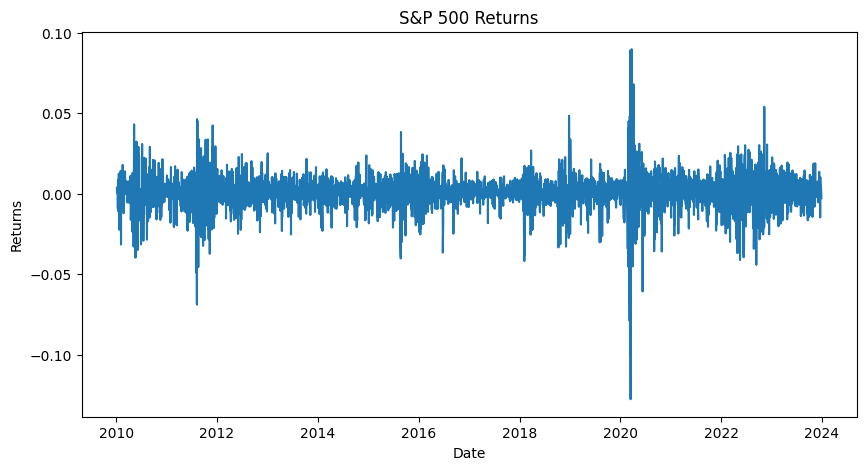

In [81]:
# visualiser le rendement 
plt.figure(figsize=(10,5))
plt.plot(returns)
plt.title("S&P 500 Returns")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.show()

In [82]:
returns.describe()


# std c-a-d la volatilité

count    3521.000000
mean        0.000408
std         0.011068
min        -0.127652
25%        -0.003891
50%         0.000643
75%         0.005677
max         0.089683
Name: ^GSPC, dtype: float64

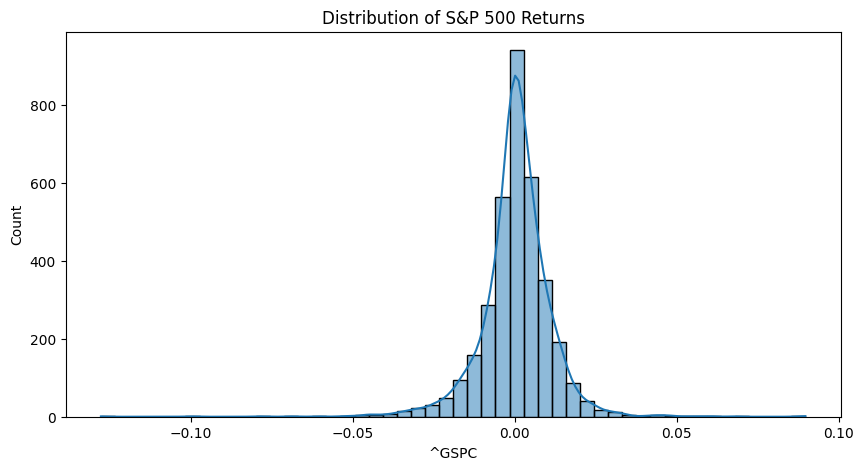

In [83]:
plt.figure(figsize=(10,5))
sns.histplot(returns, bins=50, kde=True)
plt.title("Distribution of S&P 500 Returns")
plt.show()

In [84]:
#calcule de Historical Value at Risk (VaR) pour le S&P 500.
#Calcul du VaR à 95%
VaR_95 = np.percentile(returns, 5)

print("Historical VaR (95%):", VaR_95)

Historical VaR (95%): -0.016792964912141516


Avec 95% de confiance, la perte quotidienne ne dépassera pas 0.016

In [85]:
#Calcul du VaR à 95%
VaR_99 = np.percentile(returns, 1)

print("Historical VaR (99%):", VaR_99)

Historical VaR (99%): -0.03252970698352931


Avec 99% de confiance, la perte quotidienne ne dépassera pas 0.032

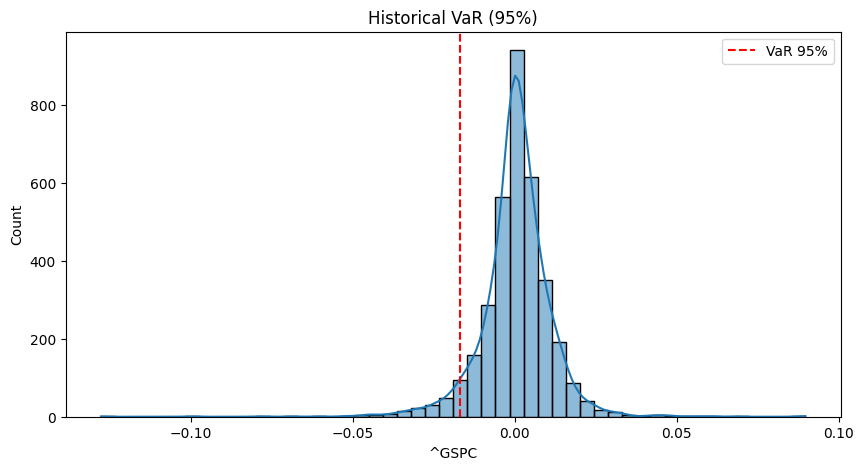

In [86]:
#Visualiser le VaR sur la distribution


plt.figure(figsize=(10,5))

sns.histplot(returns, bins=50, kde=True)

plt.axvline(VaR_95, color='red', linestyle='--', label='VaR 95%')

plt.title("Historical VaR (95%)")
plt.legend()

plt.show()




In [87]:
#arametric VaR (Variance-Covariance Method).
# cette meth suppose que les rendements suit une loi normale 



mu = returns.mean()
sigma = returns.std()

print("Mean:", mu)
print("Volatility:", sigma)

Mean: 0.00040825064867051653
Volatility: 0.0110678075502043


In [88]:
#la VaR a 95% 


VaR_param_95 = mu + (-1.65 * sigma)

print("Parametric VaR (95%):", VaR_param_95)

Parametric VaR (95%): -0.01785363180916658


In [89]:
#la VaR a 99%



VaR_param_99 = mu + (-2.33 * sigma)

print("Parametric VaR (99%):", VaR_param_99)

Parametric VaR (99%): -0.025379740943305504


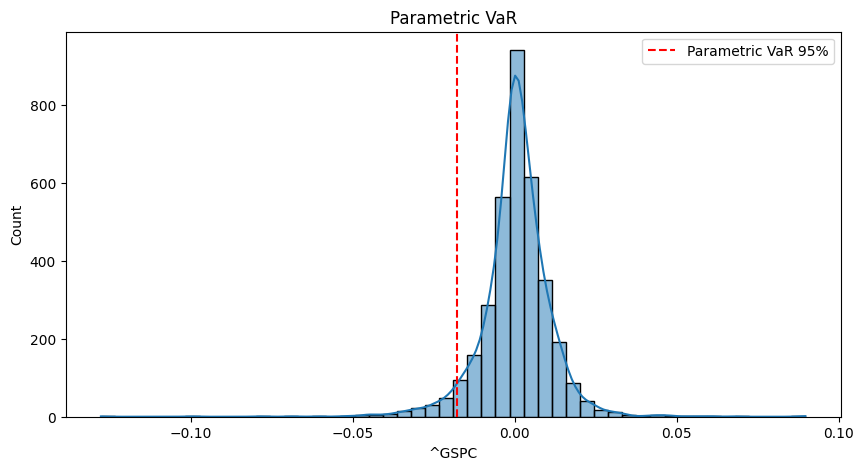

In [90]:
plt.figure(figsize=(10,5))

sns.histplot(returns, bins=50, kde=True)

plt.axvline(VaR_param_95, color='red', linestyle='--', label='Parametric VaR 95%')

plt.title("Parametric VaR")
plt.legend()

plt.show()

In [91]:
#Monte Carlo Value at Risk





n_simulations = 10000

In [92]:
#Générer les rendements simulés
sim_returns = np.random.normal(mu, sigma, n_simulations)

In [93]:
#Calcul du VaR Monte Carlo

VaR_MC_95 = np.percentile(sim_returns, 5)

print("Monte Carlo VaR (95%):", VaR_MC_95)

Monte Carlo VaR (95%): -0.017393720151618677


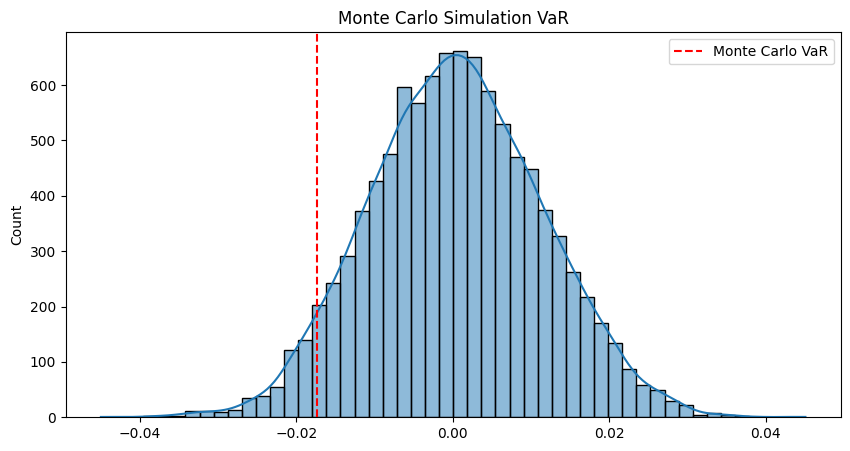

In [94]:
plt.figure(figsize=(10,5))

sns.histplot(sim_returns, bins=50, kde=True)

plt.axvline(VaR_MC_95, color='red', linestyle='--', label='Monte Carlo VaR')

plt.title("Monte Carlo Simulation VaR")
plt.legend()

plt.show()

Axe vertical (Y)

Le nombre de simulations.

Par exemple :

combien de scénarios donnent -1%

combien donnent +1%


On observe une forme en cloche.

Cela correspond à une distribution normale, car dans la simulation Monte Carlo on suppose :
returns∼N(μ,σ)

Donc :

la majorité des rendements sont proches de 0

les pertes ou gains extrêmes sont rares



Avec 95% de confiance, la perte quotidienne du portefeuille ne dépassera pas 1.8%.

In [95]:
violations = returns < VaR_95

In [96]:
n_violations = violations.sum()

print("Number of violations:", n_violations)

Number of violations: 176


In [97]:
violation_rate = n_violations / len(returns)

print("Violation rate:", violation_rate)

Violation rate: 0.049985799488781596


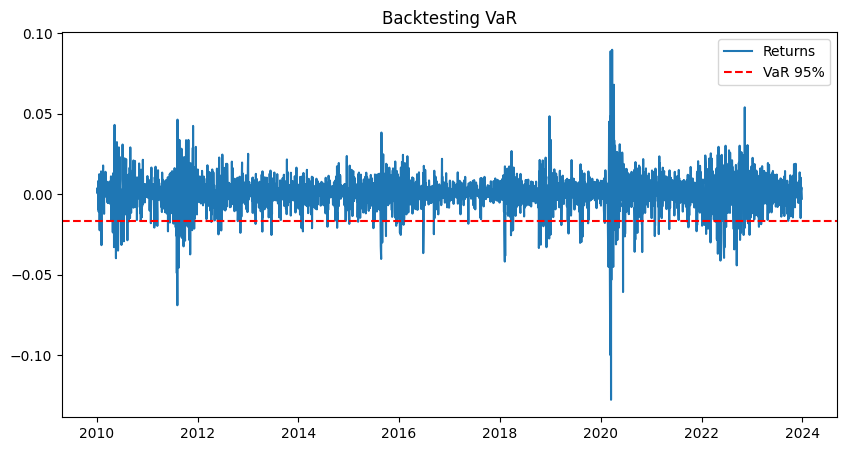

In [98]:
plt.figure(figsize=(10,5))

plt.plot(returns, label="Returns")

plt.axhline(VaR_95, color='red', linestyle='--', label="VaR 95%")

plt.title("Backtesting VaR")

plt.legend()

plt.show()

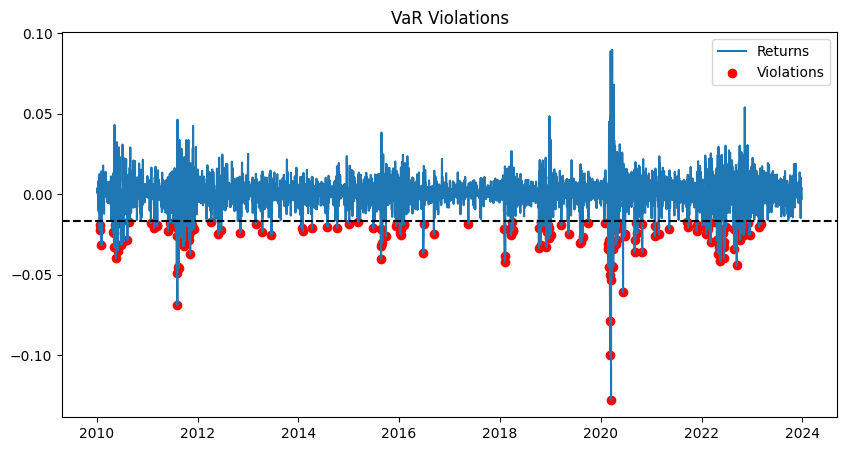

In [99]:
plt.figure(figsize=(10,5))

plt.plot(returns, label="Returns")

plt.scatter(returns.index[violations], 
            returns[violations], 
            color="red", 
            label="Violations")

plt.axhline(VaR_95, color="black", linestyle="--")

plt.legend()

plt.title("VaR Violations")

plt.show()

In [100]:
# expected shortfall : ES=E[Loss∣Loss>VaR]
ES_95 = returns[returns < VaR_95].mean()

print("Expected Shortfall (95%):", ES_95)

Expected Shortfall (95%): -0.027326053371021754


VaR 95%	perte maximale attendue = 1.8%
ES 95%	perte moyenne dans les pires cas = 2.8%

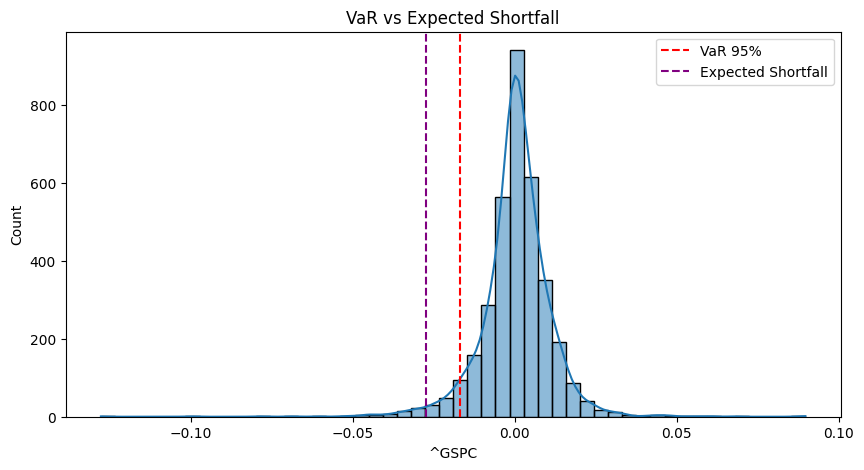

In [101]:
plt.figure(figsize=(10,5))

sns.histplot(returns, bins=50, kde=True)

plt.axvline(VaR_95, color='red', linestyle='--', label='VaR 95%')
plt.axvline(ES_95, color='purple', linestyle='--', label='Expected Shortfall')

plt.title("VaR vs Expected Shortfall")

plt.legend()

plt.show()

On va maintenant faire un graphique final qui compare toutes les mesures de risque :

Historical VaR

Parametric VaR

Monte Carlo VaR

Expected Shortfall

In [102]:
# Historical VaR
VaR_hist_95 = np.percentile(returns, 5)

# Parametric VaR
mu = returns.mean()
sigma = returns.std()
VaR_param_95 = mu - 1.65 * sigma

# Monte Carlo VaR
sim_returns = np.random.normal(mu, sigma, 10000)
VaR_MC_95 = np.percentile(sim_returns, 5)

# Expected Shortfall
ES_95 = returns[returns < VaR_hist_95].mean()

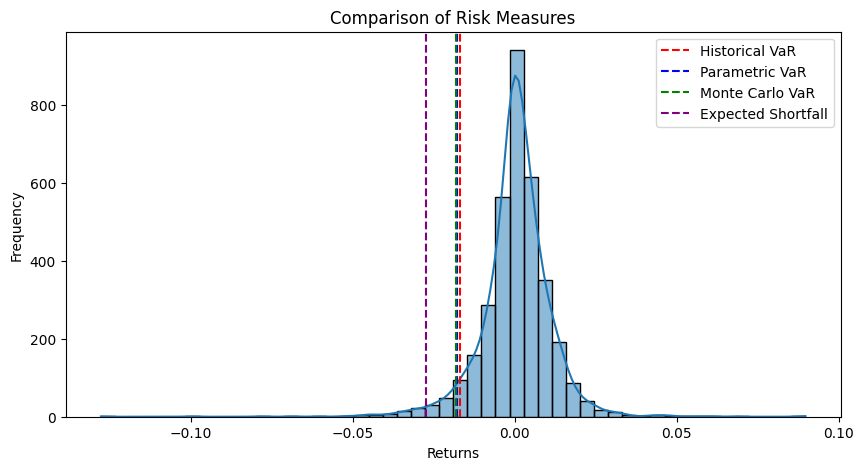

In [103]:
plt.figure(figsize=(10,5))

sns.histplot(returns, bins=50, kde=True)

plt.axvline(VaR_hist_95, color='red', linestyle='--', label='Historical VaR')
plt.axvline(VaR_param_95, color='blue', linestyle='--', label='Parametric VaR')
plt.axvline(VaR_MC_95, color='green', linestyle='--', label='Monte Carlo VaR')
plt.axvline(ES_95, color='purple', linestyle='--', label='Expected Shortfall')

plt.title("Comparison of Risk Measures")
plt.xlabel("Returns")
plt.ylabel("Frequency")

plt.legend()

plt.show()